In [25]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

In [27]:
model=ChatGroq(model='llama-3.1-8b-instant',api_key='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')
model2=ChatGroq(model='llama-3.1-8b-instant',api_key='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')


In [28]:
class parentstate(TypedDict):
    question:str
    answere_eng:str
    answere_hin:str
    

In [29]:
def translate_text(state:parentstate):
    prompt = f"""
    Translate the following text into hindi.
    Keep it natural and clear. Do not and extra content.
    Text:
    {state["answere_eng"]}
    """.strip()
    translate_text = model2.invoke(prompt).content
    return {"answere_hin":translate_text}
       

In [30]:
subgraph_builder = StateGraph(parentstate)

# add_nodes
subgraph_builder.add_node("translate_text", translate_text)

# add_adges
subgraph_builder.add_edge(START,"translate_text")
subgraph_builder.add_edge("translate_text", END)

# compile
subgraph = subgraph_builder.compile()

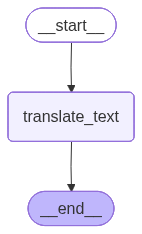

In [31]:
subgraph

In [32]:
def generate_answere(state:parentstate):
    answere = model.invoke(f"you are a helpfull assestent. Answere clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng':answer}

In [33]:
parent_builder = StateGraph(parentstate)

# add_nodes
parent_builder.add_node("answere", generate_answere)
parent_builder.add_node("translate", subgraph)

# add_adges
parent_builder.add_edge(START,"answere")
parent_builder.add_edge("answere","translate")
parent_builder.add_edge("translate", END)

# compile
subgraph = parent_builder.compile()

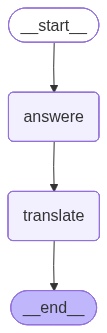

In [34]:
subgraph

In [37]:
subgraph.invoke({"question": "what is quantum physics"})

NameError: name 'answer' is not defined